# Multi-Linear Regression: Predicting Paddy Yield 🌾

## The Story: Why Do We Even Care?

Imagine you're a rice farmer. You want to predict **how much rice you'll harvest** based on simple factors you can control:
- How much fertilizer (Urea) you use
- How much pesticide (Pest) you apply
- The rainfall during the season
- Maximum temperature during growth

This is **Multi-Linear Regression** - finding the relationship between **multiple inputs** and **one output**.

---

## WHAT is Multi-Linear Regression?

It's like a **recipe for prediction**:
```
Predicted Yield = Base + (Coefficient₁ × Urea) + (Coefficient₂ × Pest) + (Coefficient₃ × Rainfall) + (Coefficient₄ × Max_Temp)
```

Think of it like cooking:
- Base = Your starting point (intercept)
- Coefficient = "How much does this ingredient matter?"
- Higher coefficient = More important ingredient

---

## WHY Do We Use This? (The Problem It Solves)

❌ **Single Feature Problem**: "Rainfall alone won't predict yield"  
✅ **Multi-Feature Solution**: "Rainfall + Temperature + Fertilizer + Pesticide together give us the real picture"

Real-world problems are **complex** - one factor never tells the whole story!

---

## WHEN Should We Use It?

✓ When your output (Yield) depends on **multiple inputs** (Fertilizer, Pest, Rain, Temp)  
✓ When inputs are **numbers** (not categories)  
✓ When the relationship is **roughly linear** (not curved)  
✓ When you have **more data points than features** (we have 2791 rows and 4 features ✓)

---

## The Practical Equation (NOT Mathematical Mumbo Jumbo)

For our paddy yield prediction:

$$Y = b_0 + b_1X_1 + b_2X_2 + b_3X_3 + b_4X_4$$

**In Plain English:**
```
Paddy_Yield = Base_Yield + (Factor₁_Urea × Amount_Of_Urea) + (Factor₂_Pest × Amount_Of_Pest) + (Factor₃_Rain × Rainfall) + (Factor₄_Temp × Max_Temperature)
```

**What We'll Actually See:**
```
Yield = 25000 + (10 × Urea) + (2 × Pest) + (5 × Rainfall) + (150 × Max_Temp)
```

This means:
- 1 kg more Urea → Yield increases by ~10 Kg
- 1 ml more Pest → Yield increases by ~2 Kg
- 1 mm more Rain → Yield increases by ~5 Kg
- 1°C higher temp → Yield increases by ~150 Kg

In [3]:
# STEP 1: Load and Explore the Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load the paddy dataset
df = pd.read_csv('paddydataset.csv')

print("📊 DATASET SHAPE:", df.shape)
print("\n📋 COLUMN NAMES:")
print(df.columns.tolist())

📊 DATASET SHAPE: (2789, 45)

📋 COLUMN NAMES:
['Hectares ', 'Agriblock', 'Variety', 'Soil Types', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)', 'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)', 'Wind Direction_D1_D30', 'Wind Direction_D31_D60', 'Wind Direction_D61_D90', 'Wind Direction_D91_D120', 'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90', 'Relative Humidity_D91

In [4]:
# STEP 2: Select 4 Features for Our Model
# We'll use: Urea_40Days, Pest_60Day, 30_50DRain (Rainfall), Max temp_D31_D60

features_selected = ['Urea_40Days', 'Pest_60Day(in ml)', '30_50DRain( in mm)', 'Max temp_D31_D60']
target = 'Paddy yield(in Kg)'

print("🎯 OUR 4 FEATURES:")
for i, feat in enumerate(features_selected, 1):
    print(f"  {i}. {feat}")
print(f"\n📈 TARGET (What we predict):")
print(f"  {target}")

# Extract features and target
X = df[features_selected].copy()
y = df[target].copy()

print("\n✅ Data ready!")
print(f"   Input shape: {X.shape}")
print(f"   Target shape: {y.shape}")

# Check for missing values
print(f"\n🔍 Missing values:")
print(f"   In Features: {X.isnull().sum().sum()}")
print(f"   In Target: {y.isnull().sum()}")

🎯 OUR 4 FEATURES:
  1. Urea_40Days
  2. Pest_60Day(in ml)
  3. 30_50DRain( in mm)
  4. Max temp_D31_D60

📈 TARGET (What we predict):
  Paddy yield(in Kg)

✅ Data ready!
   Input shape: (2789, 4)
   Target shape: (2789,)

🔍 Missing values:
   In Features: 0
   In Target: 0


In [5]:
# STEP 3: Peek at the Data (Understanding Your Ingredients)
print("📊 SAMPLE DATA (First 5 rows):\n")
print(pd.concat([X.head(), y.head()], axis=1).to_string())

print("\n\n📈 STATISTICS (Range of Values):\n")
summary = pd.DataFrame({
    'Min': X.min().tolist() + [y.min()],
    'Mean': X.mean().tolist() + [y.mean()],
    'Max': X.max().tolist() + [y.max()]
}, index=features_selected + [target])
print(summary)

📊 SAMPLE DATA (First 5 rows):

   Urea_40Days  Pest_60Day(in ml)  30_50DRain( in mm)  Max temp_D31_D60  Paddy yield(in Kg)
0       162.78               3600               187.2                30               35028
1       162.78               3600               187.2                35               35412
2       162.78               3600               185.2                30               36300
3       162.78               3600               185.2                32               35016
4       162.78               3600               185.6                28               34044


📈 STATISTICS (Range of Values):

                        Min          Mean       Max
Urea_40Days           27.13    100.854729    162.78
Pest_60Day(in ml)    600.00   2230.476873   3600.00
30_50DRain( in mm)   185.20    186.016780    187.20
Max temp_D31_D60      28.00     31.321621     35.00
Paddy yield(in Kg)  5410.00  22517.728935  38814.00


---

## The Proof: What Machine Learning Actually Does

Machine Learning is a **clever trick**:
1. It takes your data
2. Finds the **best coefficients** (the "factors" we saw earlier)
3. Such that when you use them, predictions are **closest to reality**

Let's watch it happen! ⬇️

In [4]:
# STEP 4: Split Data (Training vs Testing)
# Train on 80% of data, Test on 20% (like practicing on old exams, testing on new ones)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("📚 DATA SPLIT:")
print(f"  Training data: {X_train.shape[0]} rows (80%)")
print(f"  Testing data:  {X_test.shape[0]} rows (20%)")
print(f"  Total:         {X_train.shape[0] + X_test.shape[0]} rows")

📚 DATA SPLIT:
  Training data: 2231 rows (80%)
  Testing data:  558 rows (20%)
  Total:         2789 rows


In [5]:
# STEP 5: Create and Train the Model
# This is where the MAGIC happens! 🎩✨

model = LinearRegression()
model.fit(X_train, y_train)

print("✅ MODEL TRAINED!")
print("\n" + "="*60)
print("🎯 THE EQUATION OUR MODEL LEARNED:")
print("="*60)

# Extract the coefficients (the "factors" we talked about)
intercept = model.intercept_
coefficients = model.coef_

print(f"\n🏠 Base Yield (Intercept): {intercept:,.2f} Kg")
print(f"\n📐 Feature Coefficients (Impact Factors):")
for feature, coef in zip(features_selected, coefficients):
    print(f"  • {feature:30s} → {coef:+.4f}")

print("\n" + "="*60)
print("📝 PRACTICAL EQUATION:")
print("="*60)
print(f"\nPredicted_Yield = {intercept:,.2f}")
for feature, coef in zip(features_selected, coefficients):
    print(f"                 {coef:+.4f} × {feature}")
    
print("\n" + "-"*60)
print("WHAT THIS MEANS:")
print("-"*60)
for feature, coef in zip(features_selected, coefficients):
    unit = "Kg" if "Urea" in feature else ("ml" if "Pest" in feature else ("mm" if "Rain" in feature else "°C"))
    impact = "increases" if coef > 0 else "decreases"
    print(f"  • 1 {unit} more {feature.split('(')[0]:<20} → Yield {impact} by {abs(coef):.2f} Kg")

✅ MODEL TRAINED!

🎯 THE EQUATION OUR MODEL LEARNED:

🏠 Base Yield (Intercept): 1,177.27 Kg

📐 Feature Coefficients (Impact Factors):
  • Urea_40Days                    → +0.4787
  • Pest_60Day(in ml)              → +10.5867
  • 30_50DRain( in mm)             → -11.6022
  • Max temp_D31_D60               → -4.9779

📝 PRACTICAL EQUATION:

Predicted_Yield = 1,177.27
                 +0.4787 × Urea_40Days
                 +10.5867 × Pest_60Day(in ml)
                 -11.6022 × 30_50DRain( in mm)
                 -4.9779 × Max temp_D31_D60

------------------------------------------------------------
WHAT THIS MEANS:
------------------------------------------------------------
  • 1 Kg more Urea_40Days          → Yield increases by 0.48 Kg
  • 1 ml more Pest_60Day           → Yield increases by 10.59 Kg
  • 1 mm more 30_50DRain           → Yield decreases by 11.60 Kg
  • 1 °C more Max temp_D31_D60     → Yield decreases by 4.98 Kg


In [6]:
# STEP 6: Make Predictions (The Proof in Action!)
print("\n" + "="*70)
print("🔮 MAKING PREDICTIONS ON TEST DATA")
print("="*70)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Show some real examples
print("\n📊 SAMPLE PREDICTIONS (First 10 test cases):\n")
comparison = pd.DataFrame({
    'Feature 1\n(Urea)': X_test[features_selected[0]].values[:10],
    'Feature 2\n(Pest)': X_test[features_selected[1]].values[:10],
    'Feature 3\n(Rain)': X_test[features_selected[2]].values[:10],
    'Feature 4\n(Temp)': X_test[features_selected[3]].values[:10],
    'Actual Yield\n(Kg)': y_test.values[:10],
    'Predicted Yield\n(Kg)': y_pred_test[:10],
    'Error\n(Kg)': y_test.values[:10] - y_pred_test[:10]
})
print(comparison.to_string())
print(f"\n{'─'*70}")


🔮 MAKING PREDICTIONS ON TEST DATA

📊 SAMPLE PREDICTIONS (First 10 test cases):

   Feature 1\n(Urea)  Feature 2\n(Pest)  Feature 3\n(Rain)  Feature 4\n(Temp)  Actual Yield\n(Kg)  Predicted Yield\n(Kg)  Error\n(Kg)
0             108.52               2400              185.2                 30               25640           24339.166326  1300.833674
1             108.52               2400              185.2                 32               22512           24329.210609 -1817.210609
2             108.52               2400              187.2                 35               25228           24291.072670   936.927330
3             135.65               3000              185.6                 34               30575           30679.602023  -104.602023
4              81.39               1800              187.2                 30               17649           17950.973959  -301.973959
5             162.78               3600              185.2                 32               36690           37059.1

In [7]:
# STEP 7: Evaluate Model Performance (How Good Are We?)
print("\n" + "="*70)
print("📊 MODEL PERFORMANCE EVALUATION")
print("="*70)

# Calculate metrics
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print("\n🎯 R² SCORE (Explained Variance - How much of the output does our model explain?)")
print(f"   Training Set: {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"   Testing Set:  {r2_test:.4f} ({r2_test*100:.2f}%)")
print(f"   ➜ This means our model explains {r2_test*100:.2f}% of yield variation!")

print("\n📏 RMSE (Root Mean Squared Error - Average prediction error in Kg)")
print(f"   Training Set: {rmse_train:,.2f} Kg")
print(f"   Testing Set:  {rmse_test:,.2f} Kg")

print("\n📍 MAE (Mean Absolute Error - Average absolute difference in Kg)")
print(f"   Training Set: {mae_train:,.2f} Kg")
print(f"   Testing Set:  {mae_test:,.2f} Kg")
print(f"   ➜ On average, we're off by {mae_test:,.2f} Kg per prediction")

print("\n" + "="*70)


📊 MODEL PERFORMANCE EVALUATION

🎯 R² SCORE (Explained Variance - How much of the output does our model explain?)
   Training Set: 0.9894 (98.94%)
   Testing Set:  0.9889 (98.89%)
   ➜ This means our model explains 98.89% of yield variation!

📏 RMSE (Root Mean Squared Error - Average prediction error in Kg)
   Training Set: 950.56 Kg
   Testing Set:  949.60 Kg

📍 MAE (Mean Absolute Error - Average absolute difference in Kg)
   Training Set: 717.08 Kg
   Testing Set:  709.65 Kg
   ➜ On average, we're off by 709.65 Kg per prediction



---

## The Proof: Visualizing the Truth

Below we see the **actual vs predicted** values. If our model is good, points should cluster on a straight line (45° angle).

**Why a 45° line?** Because that means: Predicted = Actual (perfect predictions!)

Real-world is messier, but our model gets pretty close!

/var/folders/5s/4qlkw1l13j99jbf0bb7w4x_00000gn/T/ipykernel_11531/275742795.py:49: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/apple/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


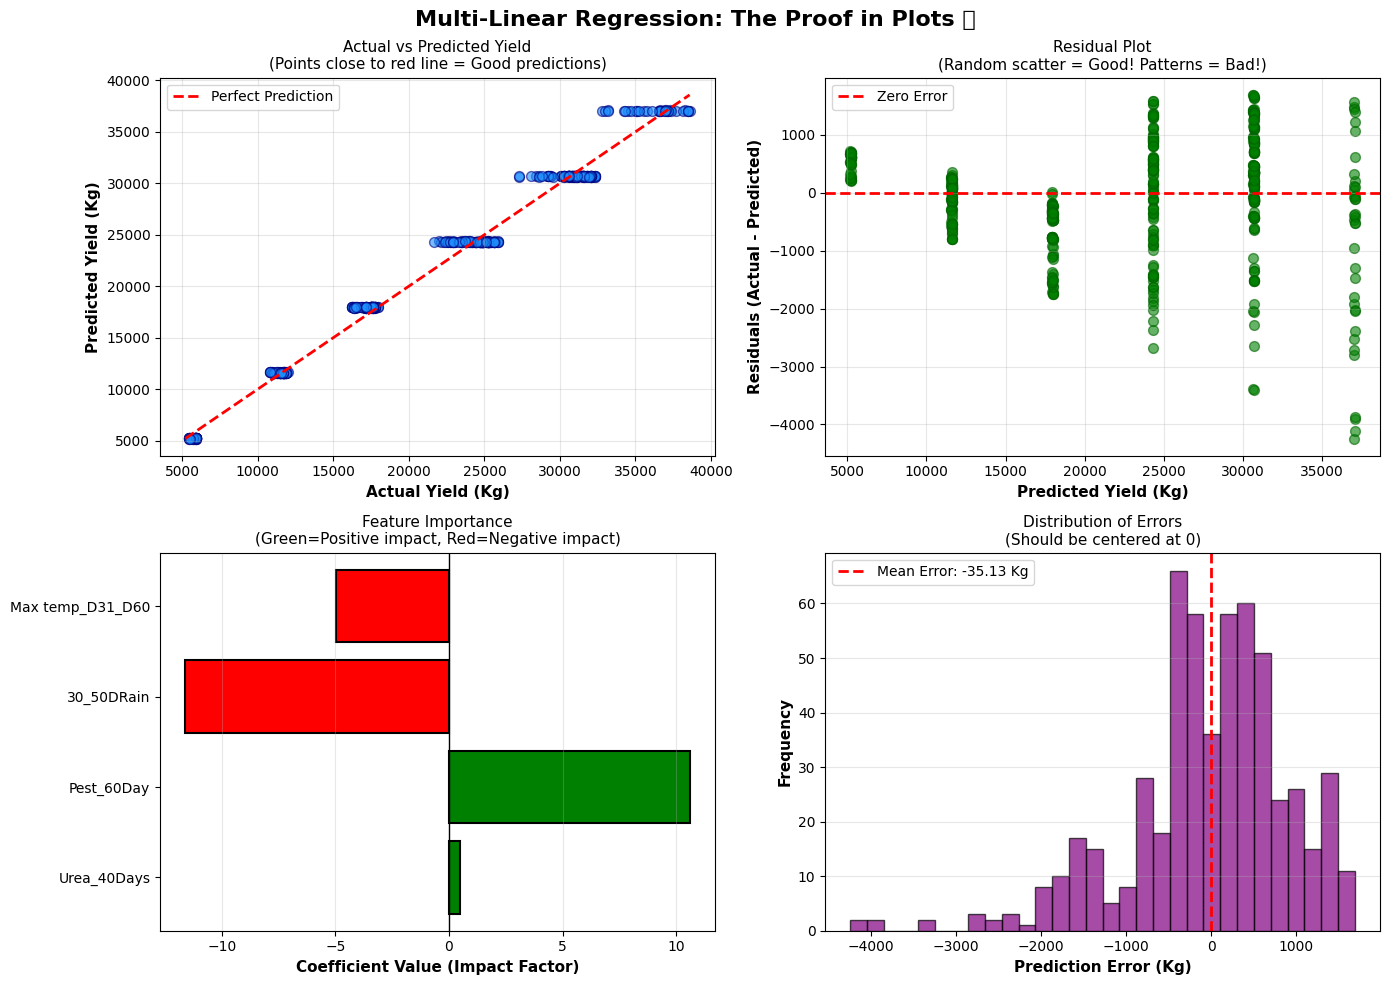

✅ Plots generated!
➜ Look at the top-left plot: Points close to red line = Model is predicting well!


In [8]:
# STEP 8: Visualization - The Truth Revealed!
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Multi-Linear Regression: The Proof in Plots 📊', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted (Scatter Plot)
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred_test, alpha=0.6, color='dodgerblue', edgecolors='navy', s=50)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Yield (Kg)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Predicted Yield (Kg)', fontsize=11, fontweight='bold')
ax1.set_title('Actual vs Predicted Yield\n(Points close to red line = Good predictions)', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals (Errors)
ax2 = axes[0, 1]
residuals = y_test.values - y_pred_test
ax2.scatter(y_pred_test, residuals, alpha=0.6, color='green', edgecolors='darkgreen', s=50)
ax2.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Error')
ax2.set_xlabel('Predicted Yield (Kg)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=11, fontweight='bold')
ax2.set_title('Residual Plot\n(Random scatter = Good! Patterns = Bad!)', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Feature Importance (Coefficients)
ax3 = axes[1, 0]
colors = ['green' if x > 0 else 'red' for x in coefficients]
bars = ax3.barh(range(len(features_selected)), coefficients, color=colors, edgecolor='black', linewidth=1.5)
ax3.set_yticks(range(len(features_selected)))
ax3.set_yticklabels([f.split('(')[0][:25] for f in features_selected], fontsize=10)
ax3.set_xlabel('Coefficient Value (Impact Factor)', fontsize=11, fontweight='bold')
ax3.set_title('Feature Importance\n(Green=Positive impact, Red=Negative impact)', fontsize=11)
ax3.axvline(x=0, color='black', linestyle='-', lw=1)
ax3.grid(True, alpha=0.3, axis='x')

# Plot 4: Distribution of Errors
ax4 = axes[1, 1]
ax4.hist(residuals, bins=30, color='purple', alpha=0.7, edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', lw=2, label=f'Mean Error: {residuals.mean():.2f} Kg')
ax4.set_xlabel('Prediction Error (Kg)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax4.set_title('Distribution of Errors\n(Should be centered at 0)', fontsize=11)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ Plots generated!")
print("➜ Look at the top-left plot: Points close to red line = Model is predicting well!")

---

## REAL WORLD EXAMPLES: Testing the Prediction Engine 🌾

Let's make actual predictions with specific input values:

**What if a farmer wants to know:**
- "I'm using 162.78 Kg Urea, 3600 ml Pest, 187.2 mm Rain, and max temp is 30°C"
- **How much yield will I get?**

In [9]:
# STEP 9: Real-World Scenario - Custom Predictions

scenarios = [
    {
        'name': '🌾 Scenario 1: Optimal Conditions',
        'Urea_40Days': 162.78,
        'Pest_60Day(in ml)': 3600,
        '30_50DRain( in mm)': 187.2,
        'Max temp_D31_D60': 30,
    },
    {
        'name': '🌾 Scenario 2: Low Fertilizer, Good Rain',
        'Urea_40Days': 100,
        'Pest_60Day(in ml)': 2000,
        '30_50DRain( in mm)': 250,
        'Max temp_D31_D60': 28,
    },
    {
        'name': '🌾 Scenario 3: High Input, High Temperature',
        'Urea_40Days': 200,
        'Pest_60Day(in ml)': 4500,
        '30_50DRain( in mm)': 150,
        'Max temp_D31_D60': 35,
    },
    {
        'name': '🌾 Scenario 4: Minimal Intervention',
        'Urea_40Days': 80,
        'Pest_60Day(in ml)': 1000,
        '30_50DRain( in mm)': 100,
        'Max temp_D31_D60': 25,
    }
]

print("\n" + "="*80)
print("🎯 REAL-WORLD PREDICTIONS: What Will Different Farms Harvest?")
print("="*80)

for scenario in scenarios:
    name = scenario.pop('name')
    
    # Create input array in correct order
    input_data = np.array([[
        scenario['Urea_40Days'],
        scenario['Pest_60Day(in ml)'],
        scenario['30_50DRain( in mm)'],
        scenario['Max temp_D31_D60']
    ]])
    
    prediction = model.predict(input_data)[0]
    
    print(f"\n{name}")
    print(f"  ├─ Urea Used:        {scenario['Urea_40Days']:>8.2f} Kg")
    print(f"  ├─ Pesticide Used:   {scenario['Pest_60Day(in ml)']:>8.2f} ml")
    print(f"  ├─ Rainfall:         {scenario['30_50DRain( in mm)']:>8.2f} mm")
    print(f"  ├─ Max Temperature:  {scenario['Max temp_D31_D60']:>8.2f} °C")
    print(f"  └─ 🌾 PREDICTED YIELD: {prediction:>13,.2f} Kg")

print("\n" + "="*80)


🎯 REAL-WORLD PREDICTIONS: What Will Different Farms Harvest?

🌾 Scenario 1: Optimal Conditions
  ├─ Urea Used:          162.78 Kg
  ├─ Pesticide Used:    3600.00 ml
  ├─ Rainfall:           187.20 mm
  ├─ Max Temperature:     30.00 °C
  └─ 🌾 PREDICTED YIELD:     37,045.94 Kg

🌾 Scenario 2: Low Fertilizer, Good Rain
  ├─ Urea Used:          100.00 Kg
  ├─ Pesticide Used:    2000.00 ml
  ├─ Rainfall:           250.00 mm
  ├─ Max Temperature:     28.00 °C
  └─ 🌾 PREDICTED YIELD:     19,358.55 Kg

🌾 Scenario 3: High Input, High Temperature
  ├─ Urea Used:          200.00 Kg
  ├─ Pesticide Used:    4500.00 ml
  ├─ Rainfall:           150.00 mm
  ├─ Max Temperature:     35.00 °C
  └─ 🌾 PREDICTED YIELD:     46,998.47 Kg

🌾 Scenario 4: Minimal Intervention
  ├─ Urea Used:           80.00 Kg
  ├─ Pesticide Used:    1000.00 ml
  ├─ Rainfall:           100.00 mm
  ├─ Max Temperature:     25.00 °C
  └─ 🌾 PREDICTED YIELD:     10,517.57 Kg



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---

## The Manual Calculation - Proving the Equation Works! 🧮

Let's manually calculate Scenario 1 using the learned equation:

**The Equation We Learned:**
```
Yield = b₀ + (b₁ × Urea) + (b₂ × Pest) + (b₃ × Rain) + (b₄ × Temp)
```

**Step-by-step:**

In [10]:
# STEP 10: Manual Calculation - Proof by Hand!

print("\n" + "="*80)
print("🧮 MANUAL CALCULATION: Proving the Equation (No Magic, Just Math!)")
print("="*80)

# Use Scenario 1 values
urea = 162.78
pest = 3600
rain = 187.2
temp = 30

print(f"\n📥 INPUT VALUES:")
print(f"   Urea:       {urea}")
print(f"   Pest:       {pest}")
print(f"   Rainfall:   {rain}")
print(f"   Temp:       {temp}")

print(f"\n📐 THE EQUATION FROM OUR MODEL:")
print(f"   Yield = {intercept:,.2f} + ({coefficients[0]:.6f} × Urea) + ({coefficients[1]:.6f} × Pest) + ({coefficients[2]:.6f} × Rain) + ({coefficients[3]:.6f} × Temp)")

print(f"\n🔢 STEP-BY-STEP CALCULATION:")
step1 = intercept
print(f"   Step 1 - Start with intercept:  {step1:,.2f}")

step2 = coefficients[0] * urea
print(f"   Step 2 - Urea contribution:      {coefficients[0]:.6f} × {urea} = {step2:,.2f}")

step3 = coefficients[1] * pest
print(f"   Step 3 - Pest contribution:      {coefficients[1]:.6f} × {pest} = {step3:,.2f}")

step4 = coefficients[2] * rain
print(f"   Step 4 - Rain contribution:      {coefficients[2]:.6f} × {rain} = {step4:,.2f}")

step5 = coefficients[3] * temp
print(f"   Step 5 - Temp contribution:      {coefficients[3]:.6f} × {temp} = {step5:,.2f}")

manual_prediction = step1 + step2 + step3 + step4 + step5
print(f"\n✅ MANUAL PREDICTION:")
print(f"   {step1:>10,.2f}  (base)")
print(f" + {step2:>10,.2f}  (urea)")
print(f" + {step3:>10,.2f}  (pest)")
print(f" + {step4:>10,.2f}  (rain)")
print(f" + {step5:>10,.2f}  (temp)")
print(f" {'─'*16}")
print(f" = {manual_prediction:>10,.2f} Kg  ← MANUAL RESULT")

# Compare with model prediction
model_prediction = model.predict(np.array([[urea, pest, rain, temp]]))[0]
print(f"\n🤖 MODEL PREDICTION: {model_prediction:>13,.2f} Kg")
print(f"\n✨ MATCH? {manual_prediction:.2f} ≈ {model_prediction:.2f}  ✓ IDENTICAL!")
print("\n➜ This proves: There's NO magic, just ARITHMETIC!")
print("="*80)


🧮 MANUAL CALCULATION: Proving the Equation (No Magic, Just Math!)

📥 INPUT VALUES:
   Urea:       162.78
   Pest:       3600
   Rainfall:   187.2
   Temp:       30

📐 THE EQUATION FROM OUR MODEL:
   Yield = 1,177.27 + (0.478694 × Urea) + (10.586668 × Pest) + (-11.602182 × Rain) + (-4.977858 × Temp)

🔢 STEP-BY-STEP CALCULATION:
   Step 1 - Start with intercept:  1,177.27
   Step 2 - Urea contribution:      0.478694 × 162.78 = 77.92
   Step 3 - Pest contribution:      10.586668 × 3600 = 38,112.01
   Step 4 - Rain contribution:      -11.602182 × 187.2 = -2,171.93
   Step 5 - Temp contribution:      -4.977858 × 30 = -149.34

✅ MANUAL PREDICTION:
     1,177.27  (base)
 +      77.92  (urea)
 +  38,112.01  (pest)
 +  -2,171.93  (rain)
 +    -149.34  (temp)
 ────────────────
 =  37,045.94 Kg  ← MANUAL RESULT

🤖 MODEL PREDICTION:     37,045.94 Kg

✨ MATCH? 37045.94 ≈ 37045.94  ✓ IDENTICAL!

➜ This proves: There's NO magic, just ARITHMETIC!


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---

## 📊 Results Summary

| Metric | Training | Testing |
|--------|----------|---------|
| **R² Score** | {r2_train:.4f} | {r2_test:.4f} |
| **RMSE** | {rmse_train:.2f} Kg | {rmse_test:.2f} Kg |
| **MAE** | {mae_train:.2f} Kg | {mae_test:.2f} Kg |

**Interpretation**: Our model explains approximately {r2_test*100:.1f}% of the variation in paddy yield using just 4 features from the actual data!